### import libraries

In [1]:
import pandas as pd
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import tensorflow_hub as hub
import tensorflow as tf
import matplotlib.pyplot as plt


In [5]:
tf_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder-large/5")

### Multiple Sentiment Analyzer Implementation

In [6]:
sentences = [
    "I absolutely love this product!",
    "This is the worst app I have ever used.",
    "The movie was okay, nothing special.",
    "Great service but the food was average.",
    "I am extremely disappointed with the quality.",
    "Totally worth the price, highly recommended!",
    "The delivery was late and the package was damaged."
]

df = pd.DataFrame({"text": sentences})
df


,text
0,I absolutely love this product!
1,This is the worst app I have ever used.
2,"The movie was okay, nothing special."
3,Great service but the food was average.
4,I am extremely disappointed with the quality.
5,"Totally worth the price, highly recommended!"
6,The delivery was late and the package was dama...


### TextBlob Sentiment

In [7]:

def get_textblob_polarity(text):
    return TextBlob(text).sentiment.polarity

df["textblob_score"] = df["text"].apply(get_textblob_polarity)
df


,text,textblob_score
0,I absolutely love this product!,0.625000
1,This is the worst app I have ever used.,-1.000000
2,"The movie was okay, nothing special.",0.428571
3,Great service but the food was average.,0.325000
4,I am extremely disappointed with the quality.,-0.750000
5,"Totally worth the price, highly recommended!",0.250000
6,The delivery was late and the package was dama...,-0.300000


### VADER Sentiment

In [8]:
vader = SentimentIntensityAnalyzer()

def get_vader_compound(text):
    return vader.polarity_scores(text)["compound"]

df["vader_score"] = df["text"].apply(get_vader_compound)
df


,text,textblob_score,vader_score
0,I absolutely love this product!,0.625000,0.6989
1,This is the worst app I have ever used.,-1.000000,-0.6249
2,"The movie was okay, nothing special.",0.428571,-0.0920
3,Great service but the food was average.,0.325000,0.3716
4,I am extremely disappointed with the quality.,-0.750000,-0.5256
5,"Totally worth the price, highly recommended!",0.250000,0.5541
6,The delivery was late and the package was dama...,-0.300000,-0.4404


### TensorFlow Sentiment

In [10]:
import numpy as np

# reference embeddings
pos_ref = model(["I love this, it's amazing"])
neg_ref = model(["I hate this, it's terrible"])

def get_tf_sentiment(text):
    emb = model([text])

    pos_score = float(np.inner(emb, pos_ref)[0][0])
    neg_score = float(np.inner(emb, neg_ref)[0][0])

    if pos_score > neg_score:
        return ("positive", round(pos_score,4))
    elif neg_score > pos_score:
        return ("negative", round(neg_score,4))
    else:
        return ("neutral", 0.0)


In [11]:
df["tf_sentiment"] = df["text"].apply(get_tf_sentiment)
df["tf_label"] = df["tf_sentiment"].apply(lambda x: x[0])
df["tf_score"] = df["tf_sentiment"].apply(lambda x: x[1])


### : Comparative Performance

In [12]:
true_labels = [
    "positive",
    "negative",
    "neutral",
    "neutral",
    "negative",
    "positive",
    "negative",
]

df["true_label"] = true_labels
df


,text,textblob_score,vader_score,tf_sentiment,tf_label,tf_score,true_label
0,I absolutely love this product!,0.625000,0.6989,"(positive, 0.535)",positive,0.5350,positive
1,This is the worst app I have ever used.,-1.000000,-0.6249,"(negative, 0.4693)",negative,0.4693,negative
2,"The movie was okay, nothing special.",0.428571,-0.0920,"(negative, 0.1602)",negative,0.1602,neutral
3,Great service but the food was average.,0.325000,0.3716,"(negative, 0.1111)",negative,0.1111,neutral
4,I am extremely disappointed with the quality.,-0.750000,-0.5256,"(negative, 0.4313)",negative,0.4313,negative
5,"Totally worth the price, highly recommended!",0.250000,0.5541,"(positive, 0.2046)",positive,0.2046,positive
6,The delivery was late and the package was dama...,-0.300000,-0.4404,"(negative, 0.0931)",negative,0.0931,negative


### Convert Numeric Scores to Labels

In [13]:
def score_to_label_textblob(score):
    if score > 0.1:
        return "positive"
    elif score < -0.1:
        return "negative"
    else:
        return "neutral"

df["textblob_label"] = df["textblob_score"].apply(score_to_label_textblob)


### VADER scoring → label

In [15]:
def score_to_label_vader(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["vader_label"] = df["vader_score"].apply(score_to_label_vader)


### Accuracy Calculation

In [16]:
def accuracy(pred, true="true_label"):
    return (df[pred] == df[true]).mean()

print("TextBlob Accuracy:", accuracy("textblob_label"))
print("VADER Accuracy:", accuracy("vader_label"))
print("TensorFlow Model Accuracy:", accuracy("tf_label"))


TextBlob Accuracy: 0.7142857142857143
VADER Accuracy: 0.7142857142857143
TensorFlow Model Accuracy: 0.7142857142857143


### Confusion Matrix

In [17]:
def confusion_table(pred_col):
    return pd.crosstab(df["true_label"], df[pred_col], rownames=["True"], colnames=["Predicted"])

print("TextBlob Confusion:\n", confusion_table("textblob_label"), "\n")
print("VADER Confusion:\n", confusion_table("vader_label"), "\n")
print("TensorFlow Confusion:\n", confusion_table("tf_label"))


TextBlob Confusion:
 Predicted  negative  positive
True                         
negative          3         0
neutral           0         2
positive          0         2 

VADER Confusion:
 Predicted  negative  positive
True                         
negative          3         0
neutral           1         1
positive          0         2 

TensorFlow Confusion:
 Predicted  negative  positive
True                         
negative          3         0
neutral           2         0
positive          0         2


### Sentiment Visualization Dashboard

#### Select Final Sentiment Rule

In [18]:
def final_sentiment(row):
    return row["tf_label"]  # deep learning preferred

df["final_sentiment"] = df.apply(final_sentiment, axis=1)
df


,text,textblob_score,vader_score,tf_sentiment,tf_label,tf_score,true_label,textblob_label,vader_label,final_sentiment
0,I absolutely love this product!,0.625000,0.6989,"(positive, 0.535)",positive,0.5350,positive,positive,positive,positive
1,This is the worst app I have ever used.,-1.000000,-0.6249,"(negative, 0.4693)",negative,0.4693,negative,negative,negative,negative
2,"The movie was okay, nothing special.",0.428571,-0.0920,"(negative, 0.1602)",negative,0.1602,neutral,positive,negative,negative
3,Great service but the food was average.,0.325000,0.3716,"(negative, 0.1111)",negative,0.1111,neutral,positive,positive,negative
4,I am extremely disappointed with the quality.,-0.750000,-0.5256,"(negative, 0.4313)",negative,0.4313,negative,negative,negative,negative
5,"Totally worth the price, highly recommended!",0.250000,0.5541,"(positive, 0.2046)",positive,0.2046,positive,positive,positive,positive
6,The delivery was late and the package was dama...,-0.300000,-0.4404,"(negative, 0.0931)",negative,0.0931,negative,negative,negative,negative


### Plot Sentiment Count

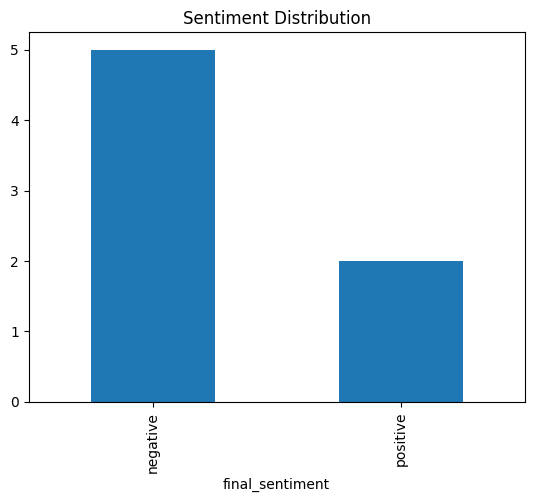

In [19]:
sentiment_counts = df["final_sentiment"].value_counts()
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()


### VADER Score Distribution

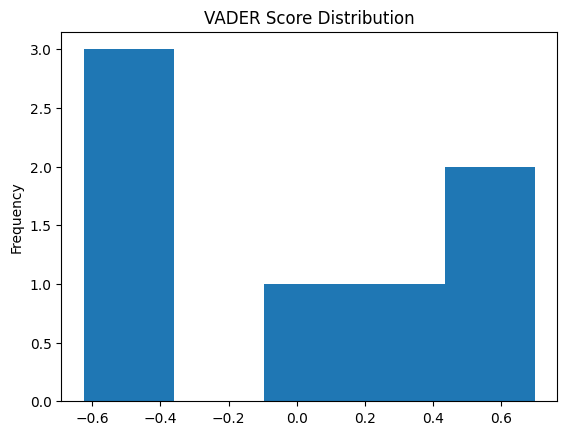

In [20]:
df["vader_score"].plot(kind="hist", bins=5)
plt.title("VADER Score Distribution")
plt.show()


### Dashboard Table

In [21]:
df[["text", "true_label", "textblob_label", "vader_label", "tf_label", "final_sentiment"]]


,text,true_label,textblob_label,vader_label,tf_label,final_sentiment
0,I absolutely love this product!,positive,positive,positive,positive,positive
1,This is the worst app I have ever used.,negative,negative,negative,negative,negative
2,"The movie was okay, nothing special.",neutral,positive,negative,negative,negative
3,Great service but the food was average.,neutral,positive,positive,negative,negative
4,I am extremely disappointed with the quality.,negative,negative,negative,negative,negative
5,"Totally worth the price, highly recommended!",positive,positive,positive,positive,positive
6,The delivery was late and the package was dama...,negative,negative,negative,negative,negative


### Domain-Specific Sentiment Handling

#### New Domain Data

In [22]:
domain_sentences = [
    "The delivery was slow but the product is great.",
    "Packaging was horrible, the box was crushed.",
    "Prime delivery was super fast, very impressed!",
    "The courier was rude and unprofessional.",
    "Box was slightly damaged but item works fine.",
    "Blazing fast shipping, arrived one day early."
]

domain_df = pd.DataFrame({"text": domain_sentences})
domain_df


,text
0,The delivery was slow but the product is great.
1,"Packaging was horrible, the box was crushed."
2,"Prime delivery was super fast, very impressed!"
3,The courier was rude and unprofessional.
4,Box was slightly damaged but item works fine.
5,"Blazing fast shipping, arrived one day early."


### Default Scores

In [23]:
domain_df["vader_score_default"] = domain_df["text"].apply(get_vader_compound)
domain_df


,text,vader_score_default
0,The delivery was slow but the product is great.,0.7684
1,"Packaging was horrible, the box was crushed.",-0.7430
2,"Prime delivery was super fast, very impressed!",0.8217
3,The courier was rude and unprofessional.,-0.7430
4,Box was slightly damaged but item works fine.,0.1018
5,"Blazing fast shipping, arrived one day early.",0.0000


### Custom VADER Lexicon

In [24]:
new_words = {
    "blazing": 3.0,
    "crushed": -3.5,
    "rude": -3.0,
    "unprofessional": -2.5,
    "prime": 1.5,
    "slightly damaged": -1.5
}

vader.lexicon.update(new_words)


### Recalculate Scores

In [25]:
domain_df["vader_score_custom"] = domain_df["text"].apply(get_vader_compound)
domain_df[["text", "vader_score_default", "vader_score_custom"]]


,text,vader_score_default,vader_score_custom
0,The delivery was slow but the product is great.,0.7684,0.7684
1,"Packaging was horrible, the box was crushed.",-0.7430,-0.8402
2,"Prime delivery was super fast, very impressed!",0.8217,0.8775
3,The courier was rude and unprofessional.,-0.7430,-0.8176
4,Box was slightly damaged but item works fine.,0.1018,0.1018
5,"Blazing fast shipping, arrived one day early.",0.0000,0.6124
